# D7 — Statistical Analysis of BIS Macroeconomic Time Series

## Objective

In the previous notebooks, we learned how to discover BIS SDMX metadata, retrieve official macroeconomic data, and build analysis-ready datasets.

The objective of this notebook is to move beyond data preparation and focus on **understanding the statistical characteristics of a macroeconomic time series**.

Using the BIS Total Credit dataset, we will investigate how economists and data scientists examine a time series before selecting forecasting or econometric models.

Rather than predicting future values, this notebook emphasizes exploratory statistical analysis, trend identification, growth measurement, volatility assessment, and stationarity diagnostics.

---

## Learning Objectives

By the end of this notebook, we will be able to:

- Retrieve a BIS SDMX time series
- Build an analysis-ready dataset
- Compute descriptive statistics
- Analyze rolling trends and volatility
- Measure quarter-on-quarter and year-on-year growth
- Examine the statistical distribution of the series
- Evaluate autocorrelation
- Test for stationarity using standard statistical tests
- Interpret the statistical behaviour of macroeconomic data

---

## Workflow

```text
Retrieve BIS SDMX Data
        │
        ▼
Analysis-Ready Dataset
        │
        ▼
Descriptive Statistics
        │
        ▼
Rolling Trend Analysis
        │
        ▼
Growth Rate Analysis
        │
        ▼
Distribution Analysis
        │
        ▼
Autocorrelation Analysis
        │
        ▼
Stationarity Diagnostics
        │
        ▼
Economic Interpretation
```

In [1]:
# ----------------------------------------------------
# Imports
# ----------------------------------------------------

import sdmx
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew
from scipy.stats import kurtosis

from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12, 5)

In [6]:
# ----------------------------------------------------
# Analysis Configuration
# ----------------------------------------------------

DATAFLOW_ID = "WS_TC"

COUNTRY = "IN"

BORROWER = "P"

LENDER = "A"

VALUATION = "M"

UNIT = "770"

ADJUSTMENT = "A"

FREQUENCY = "Q"

In [8]:
# ----------------------------------------------------
# Connect to BIS
# ----------------------------------------------------

client = sdmx.Client("BIS")

print(client.source.id)
print(client.source.url)

BIS
https://stats.bis.org/api/v1


In [9]:
# ----------------------------------------------------
# Retrieve Data
# ----------------------------------------------------

query_key = (
    f"{FREQUENCY}."
    f"{COUNTRY}."
    f"{BORROWER}."
    f"{LENDER}."
    f"{VALUATION}."
    f"{UNIT}."
    f"{ADJUSTMENT}"
)

print(query_key)

response = client.data(
    "WS_TC",
    key=query_key
)

dataset = response.data[0]

print("Series :", len(dataset.series))
print("Observations :", len(dataset.obs))

Q.IN.P.A.M.770.A


xml.Reader got no structure=… argument for StructureSpecificData


Series : 1
Observations : 299


In [11]:
type(dataset)

sdmx.model.v21.StructureSpecificDataSet

In [12]:
# ----------------------------------------------------
# Build Analysis Dataset
# ----------------------------------------------------

rows = []

for series_key, observations in dataset.series.items():

    metadata = {
        dim: value.value
        for dim, value in series_key.values.items()
    }

    for obs in observations:

        row = metadata.copy()

        row["TIME_PERIOD"] = obs.dimension.values[0].value
        row["OBS_VALUE"] = float(obs.value)

        rows.append(row)

df = pd.DataFrame(rows)

df["Quarter"] = pd.PeriodIndex(
    df["TIME_PERIOD"],
    freq="Q"
)

df["Year"] = df["Quarter"].dt.year

df = df.sort_values("Quarter").reset_index(drop=True)

print(df.shape)
display(df.head())

(299, 14)


,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,Quarter,Year
0,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1951-Q2,25.2,1951Q2,1951
1,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1951-Q3,23.4,1951Q3,1951
2,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1951-Q4,23.0,1951Q4,1951
3,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1952-Q1,23.1,1952Q1,1952
4,IN,P,A,M,770,A,Q,India - Credit to Private non-financial sector...,0,367,1952-Q2,23.3,1952Q2,1952


## Question 1

### How has the Credit-to-GDP ratio evolved over time?

We begin by examining the historical trajectory of the series to identify long-term trends and notable periods of change.

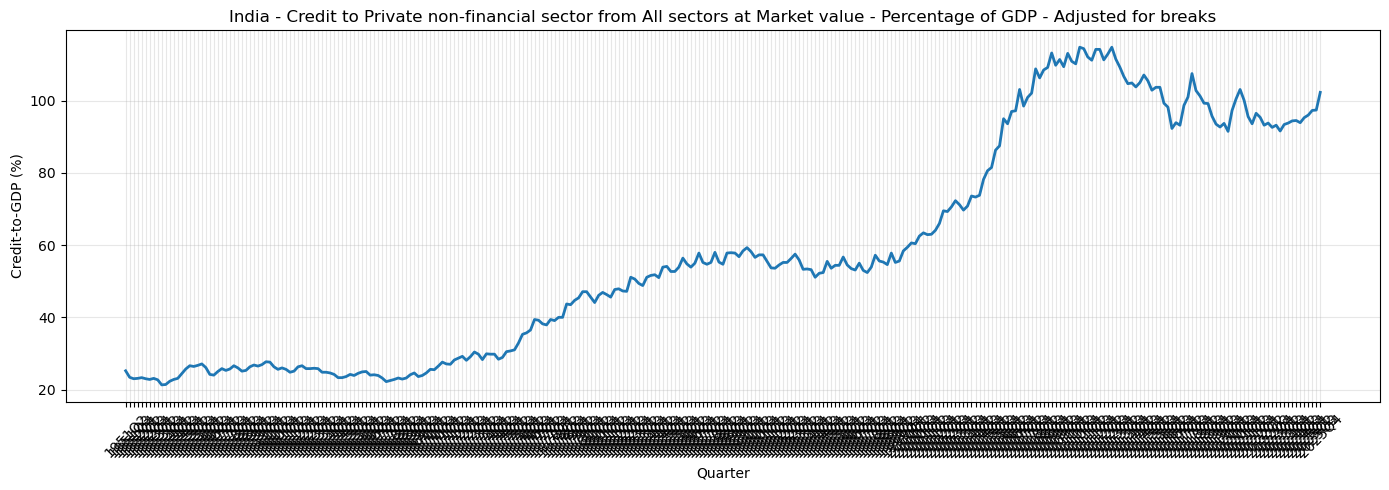

In [14]:
# ----------------------------------------------------
# Credit-to-GDP Time Series
# How has the Credit-to-GDP ratio evolved over time?
# ----------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(
    df["Quarter"].astype(str),
    df["OBS_VALUE"],
    linewidth=2
)

plt.title(df["TITLE_TS"].iloc[0])

plt.xlabel("Quarter")
plt.ylabel("Credit-to-GDP (%)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [16]:
# ----------------------------------------------------
# Statistical Summary
# What are the basic characteristics of this series?
# ----------------------------------------------------

summary = pd.DataFrame({

    "Metric": [

        "Observations",
        "Start Quarter",
        "End Quarter",
        "Mean",
        "Median",
        "Minimum",
        "Maximum",
        "Standard Deviation",
        "Variance",
        "Skewness",
        "Kurtosis"

    ],

    "Value": [

        len(df),
        str(df["Quarter"].min()),
        str(df["Quarter"].max()),
        round(df["OBS_VALUE"].mean(), 2),
        round(df["OBS_VALUE"].median(), 2),
        round(df["OBS_VALUE"].min(), 2),
        round(df["OBS_VALUE"].max(), 2),
        round(df["OBS_VALUE"].std(), 2),
        round(df["OBS_VALUE"].var(), 2),
        round(skew(df["OBS_VALUE"]), 2),
        round(kurtosis(df["OBS_VALUE"]), 2)

    ]

})

summary

,Metric,Value
0,Observations,299
1,Start Quarter,1951Q2
2,End Quarter,2025Q4
3,Mean,57.86
4,Median,53.9
5,Minimum,21.3
6,Maximum,114.8
7,Standard Deviation,30.38
8,Variance,923.24
9,Skewness,0.47


## Question 2

### How quickly is credit expanding?

Quarter-on-quarter and year-on-year growth rates help us distinguish short-term fluctuations from sustained changes in credit conditions.

In [17]:
# ----------------------------------------------------
# Quarter-on-Quarter Growth
# How quickly is credit expanding?
# ----------------------------------------------------

df["QoQ_Growth"] = (

    df["OBS_VALUE"]

    .pct_change()

    * 100

)

df[
    [
        "Quarter",
        "OBS_VALUE",
        "QoQ_Growth"
    ]
].tail()

,Quarter,OBS_VALUE,QoQ_Growth
294,2024Q4,95.3,1.490948
295,2025Q1,96.0,0.734523
296,2025Q2,97.3,1.354167
297,2025Q3,97.4,0.102775
298,2025Q4,102.3,5.030801


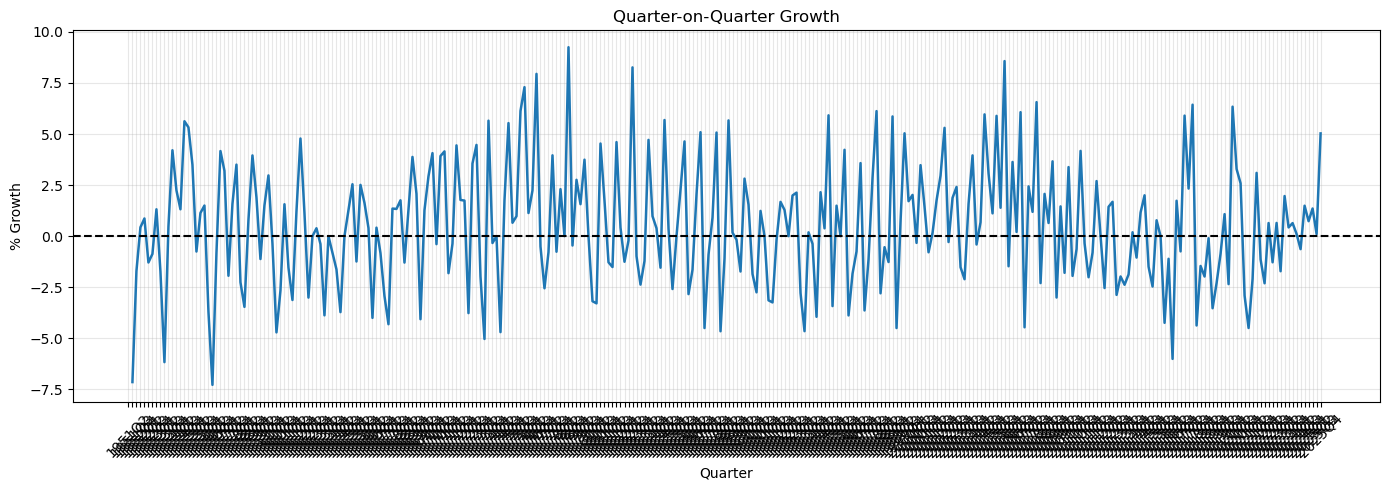

In [18]:
# ----------------------------------------------------
# Quarter-on-Quarter Growth
# ----------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(

    df["Quarter"].astype(str),

    df["QoQ_Growth"],

    linewidth=1.8

)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Quarter-on-Quarter Growth")

plt.xlabel("Quarter")

plt.ylabel("% Growth")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [19]:
# ----------------------------------------------------
# Year-on-Year Growth
# ----------------------------------------------------

df["YoY_Growth"] = (

    df["OBS_VALUE"]

    .pct_change(4)

    * 100

)

df[
    [
        "Quarter",
        "YoY_Growth"
    ]
].tail()

,Quarter,YoY_Growth
294,2024Q4,1.599147
295,2025Q1,1.694915
296,2025Q2,2.962963
297,2025Q3,3.727370
298,2025Q4,7.345226


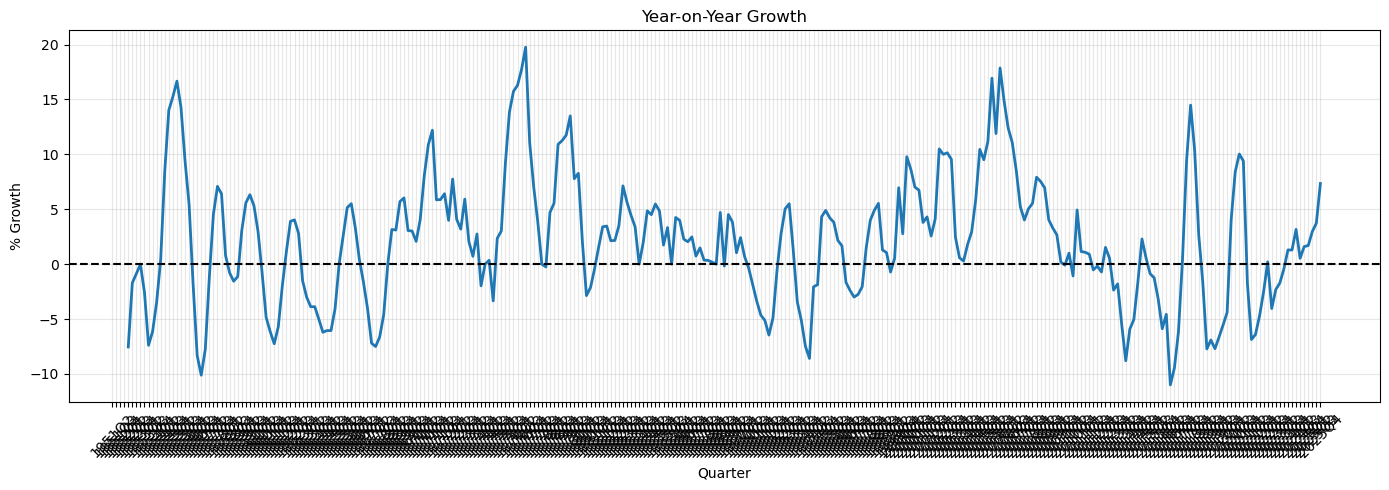

In [20]:
# ----------------------------------------------------
# Year-on-Year Growth
# ----------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(

    df["Quarter"].astype(str),

    df["YoY_Growth"],

    linewidth=2

)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Year-on-Year Growth")

plt.xlabel("Quarter")

plt.ylabel("% Growth")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Question 3

### Is the long-term trend changing?

Individual quarterly observations can be noisy. A rolling average smooths short-term fluctuations and helps reveal the underlying long-term trend in the Credit-to-GDP ratio.

In [21]:
# ----------------------------------------------------
# Rolling Mean (8 Quarters)
# ----------------------------------------------------

WINDOW = 8

df["Rolling_Mean"] = (
    df["OBS_VALUE"]
    .rolling(window=WINDOW)
    .mean()
)

df[
    [
        "Quarter",
        "OBS_VALUE",
        "Rolling_Mean"
    ]
].tail()

,Quarter,OBS_VALUE,Rolling_Mean
294,2024Q4,95.3,93.7625
295,2025Q1,96.0,94.1125
296,2025Q2,97.3,94.8250
297,2025Q3,97.4,95.3250
298,2025Q4,102.3,96.3875


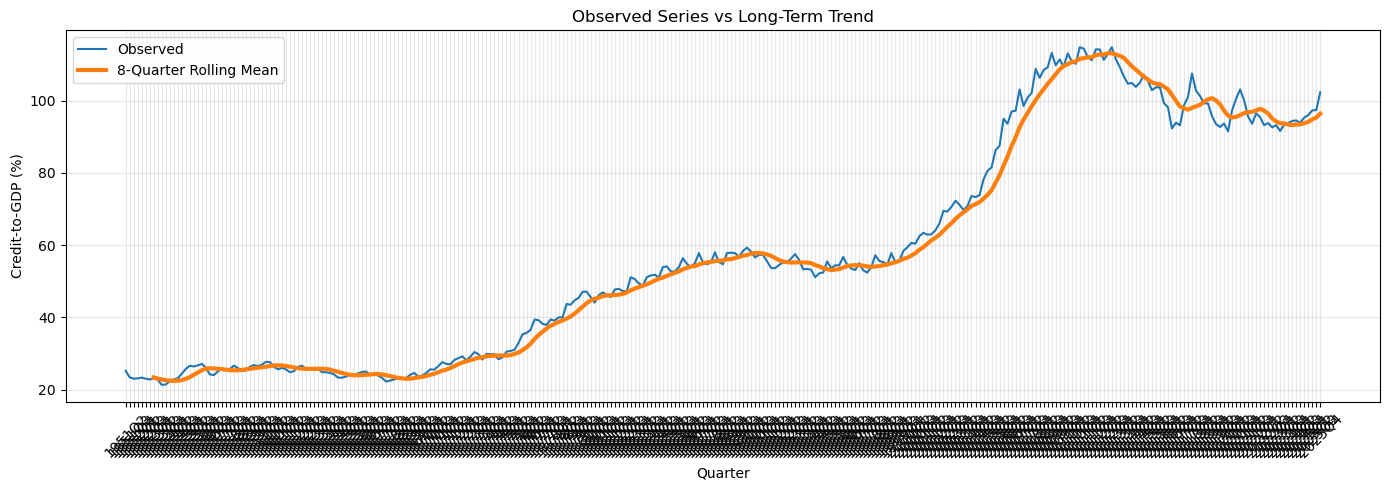

In [22]:
# ----------------------------------------------------
# Trend vs Rolling Mean
# ----------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(
    df["Quarter"].astype(str),
    df["OBS_VALUE"],
    label="Observed",
    linewidth=1.5
)

plt.plot(
    df["Quarter"].astype(str),
    df["Rolling_Mean"],
    label=f"{WINDOW}-Quarter Rolling Mean",
    linewidth=3
)

plt.title("Observed Series vs Long-Term Trend")

plt.xlabel("Quarter")
plt.ylabel("Credit-to-GDP (%)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## Question 4

### Has volatility changed over time?

Rolling standard deviation measures how much the Credit-to-GDP ratio fluctuates within a moving time window. Increasing volatility may indicate greater economic uncertainty or structural change.

In [23]:
# ----------------------------------------------------
# Rolling Volatility
# ----------------------------------------------------

df["Rolling_Std"] = (
    df["OBS_VALUE"]
    .rolling(window=WINDOW)
    .std()
)

df[
    [
        "Quarter",
        "Rolling_Std"
    ]
].tail()

,Quarter,Rolling_Std
294,2024Q4,1.099269
295,2025Q1,1.318481
296,2025Q2,1.306850
297,2025Q3,1.441973
298,2025Q4,2.721574


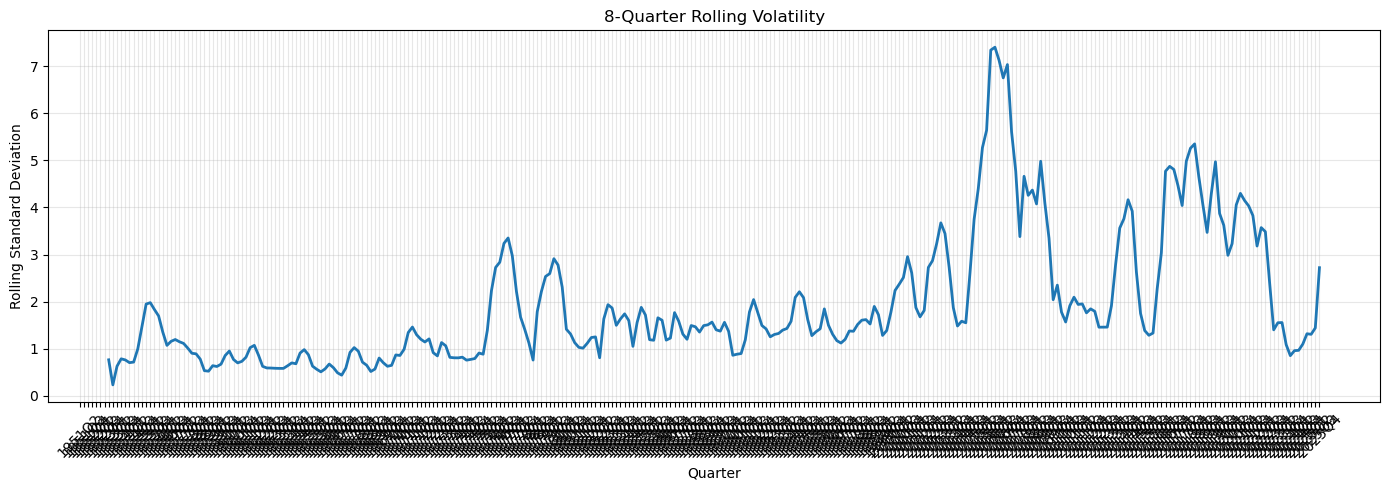

In [24]:
# ----------------------------------------------------
# Rolling Volatility
# ----------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(
    df["Quarter"].astype(str),
    df["Rolling_Std"],
    linewidth=2
)

plt.title(f"{WINDOW}-Quarter Rolling Volatility")

plt.xlabel("Quarter")
plt.ylabel("Rolling Standard Deviation")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Question 5

### Does the series exhibit persistence over time?

Macroeconomic variables often exhibit strong temporal dependence, meaning that current values are influenced by past observations.

Autocorrelation analysis helps quantify this persistence by measuring the relationship between observations at different time lags. 

In [25]:
# ----------------------------------------------------
# Autocorrelation Analysis
# ----------------------------------------------------

MAX_LAG = 12

autocorr = pd.DataFrame({

    "Lag": range(1, MAX_LAG + 1),

    "Autocorrelation": [

        df["OBS_VALUE"].autocorr(lag=i)

        for i in range(1, MAX_LAG + 1)

    ]

})

autocorr

,Lag,Autocorrelation
0,1,0.998100
1,2,0.996393
2,3,0.994389
3,4,0.992910
4,5,0.989863
5,6,0.987619
6,7,0.985697
7,8,0.984121
8,9,0.980965
9,10,0.978013


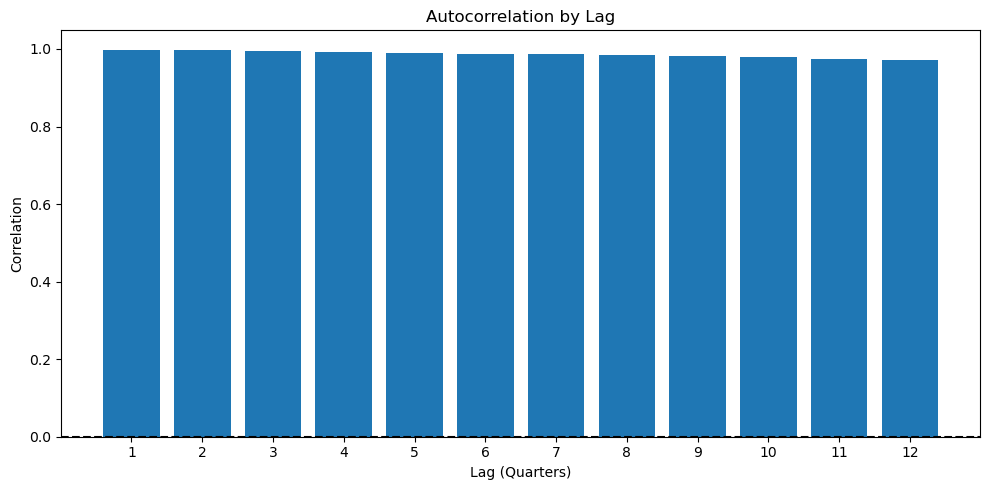

In [26]:
# ----------------------------------------------------
# Autocorrelation Plot
# ----------------------------------------------------

plt.figure(figsize=(10,5))

plt.bar(

    autocorr["Lag"],

    autocorr["Autocorrelation"]

)

plt.axhline(

    0,

    color="black",

    linestyle="--"

)

plt.title("Autocorrelation by Lag")

plt.xlabel("Lag (Quarters)")

plt.ylabel("Correlation")

plt.xticks(range(1, MAX_LAG + 1))

plt.tight_layout()

plt.show()

This means:

Every quarter looks extremely similar to the previous quarter.
Even observations 3 years apart (12 quarters) remain highly correlated.
The series has very strong persistence.

Economically, this makes sense because the Credit-to-GDP ratio is a slow-moving macroeconomic indicator, not something that changes dramatically every quarter.

<Figure size 1000x500 with 0 Axes>

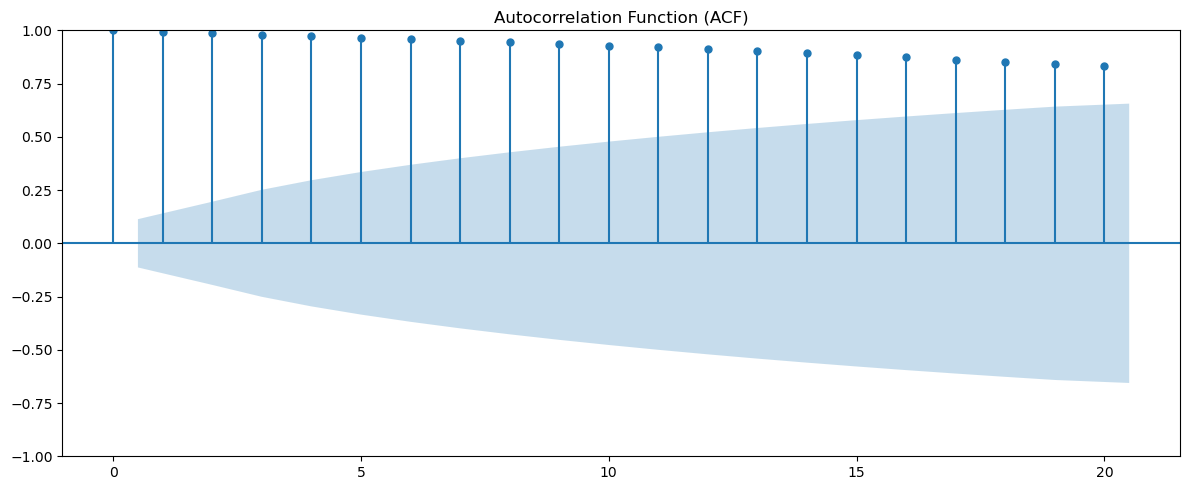

In [32]:
# ----------------------------------------------------
# Autocorrelation Function (ACF)
# ----------------------------------------------------

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    df["OBS_VALUE"],
    lags=20
)

plt.title("Autocorrelation Function (ACF)")

plt.tight_layout()

plt.show()

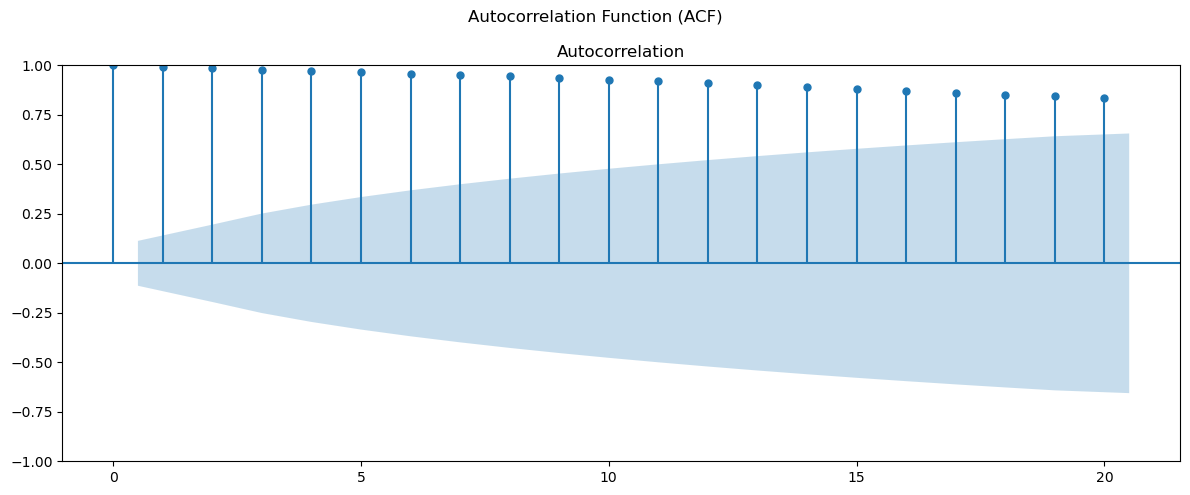

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig = plot_acf(
    df["OBS_VALUE"],
    lags=20,
)

fig.suptitle("Autocorrelation Function (ACF)")

plt.tight_layout()
plt.show()

In [37]:
# ----------------------------------------------------
# Interpretation
# ----------------------------------------------------

# • High autocorrelation at small lags indicates strong persistence.
# • A slow decay in the ACF suggests a long-term trend.
# • This behaviour is common in macroeconomic time series.
# • The result indicates that the original series is likely non-stationary.


## Question 6

### Is the series stationary?

Many classical time series forecasting methods assume that the statistical properties of a series remain stable over time.

The Augmented Dickey-Fuller (ADF) test evaluates whether the series contains a unit root. A stationary series is generally easier to model, while a non-stationary series often requires transformation before forecasting.

In [27]:
# ----------------------------------------------------
# Augmented Dickey-Fuller Test
# ----------------------------------------------------

from statsmodels.tsa.stattools import adfuller

result = adfuller(df["OBS_VALUE"])

print(f"ADF Statistic : {result[0]:.4f}")

print(f"P-value       : {result[1]:.4f}")

print()

print("Critical Values")

for key, value in result[4].items():

    print(f"{key}: {value:.4f}")

ADF Statistic : -0.5298
P-value       : 0.8861

Critical Values
1%: -3.4537
5%: -2.8718
10%: -2.5722


In [28]:
# ----------------------------------------------------
# Interpretation
# ----------------------------------------------------

p_value = result[1]

if p_value < 0.05:

    print("Conclusion:")
    print("The series appears to be stationary.")
    print("The null hypothesis of a unit root is rejected.")

else:

    print("Conclusion:")
    print("The series appears to be non-stationary.")
    print("The null hypothesis of a unit root cannot be rejected.")

Conclusion:
The series appears to be non-stationary.
The null hypothesis of a unit root cannot be rejected.


## Question 7

### Can differencing improve stationarity?

Macroeconomic variables frequently exhibit long-term trends that violate stationarity assumptions.

A common transformation is first-order differencing, which measures the change between consecutive observations. This removes deterministic trends and often produces a stationary series suitable for forecasting models such as ARIMA.

In [29]:
# ----------------------------------------------------
# First Difference
# ----------------------------------------------------

df["First_Difference"] = df["OBS_VALUE"].diff()

df[
    [
        "Quarter",
        "OBS_VALUE",
        "First_Difference"
    ]
].tail()

,Quarter,OBS_VALUE,First_Difference
294,2024Q4,95.3,1.4
295,2025Q1,96.0,0.7
296,2025Q2,97.3,1.3
297,2025Q3,97.4,0.1
298,2025Q4,102.3,4.9


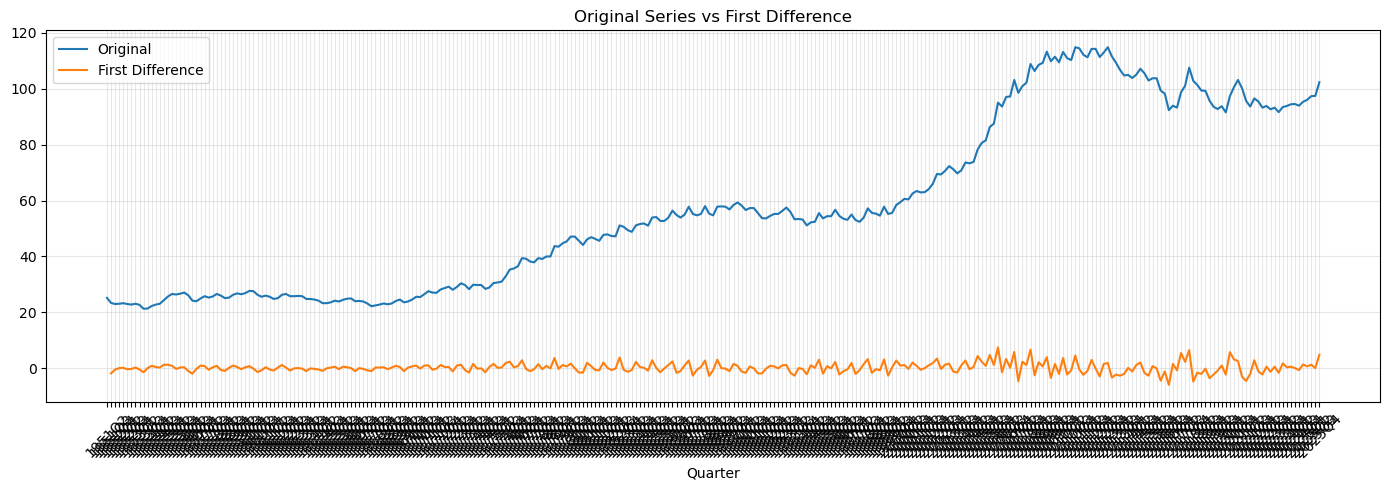

In [30]:
# ----------------------------------------------------
# Original vs First Difference
# ----------------------------------------------------

plt.figure(figsize=(14,5))

plt.plot(

    df["Quarter"].astype(str),

    df["OBS_VALUE"],

    label="Original"

)

plt.plot(

    df["Quarter"].astype(str),

    df["First_Difference"],

    label="First Difference"

)

plt.title("Original Series vs First Difference")

plt.xlabel("Quarter")

plt.xticks(rotation=45)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [31]:
# ----------------------------------------------------
# ADF Test (First Difference)
# ----------------------------------------------------

diff_series = df["First_Difference"].dropna()

result_diff = adfuller(diff_series)

print(f"ADF Statistic : {result_diff[0]:.4f}")

print(f"P-value       : {result_diff[1]:.4f}")

ADF Statistic : -2.6798
P-value       : 0.0776


# Conclusions

This notebook explored the statistical characteristics of the BIS Credit-to-GDP time series for India.

The analysis demonstrated:

- The series exhibits a clear long-term upward trend.
- Quarter-on-quarter and year-on-year growth rates reveal changes in credit expansion over time.
- Rolling statistics highlight evolving trend and volatility.
- The Autocorrelation Function (ACF) confirms strong temporal persistence.
- The Augmented Dickey-Fuller (ADF) test assesses whether the series is stationary.
- First-order differencing illustrates how the series can be transformed for forecasting applications.

Having completed exploratory time series analysis and diagnostic testing, the dataset is now ready for forecasting.

